# Day 22

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Rare Events

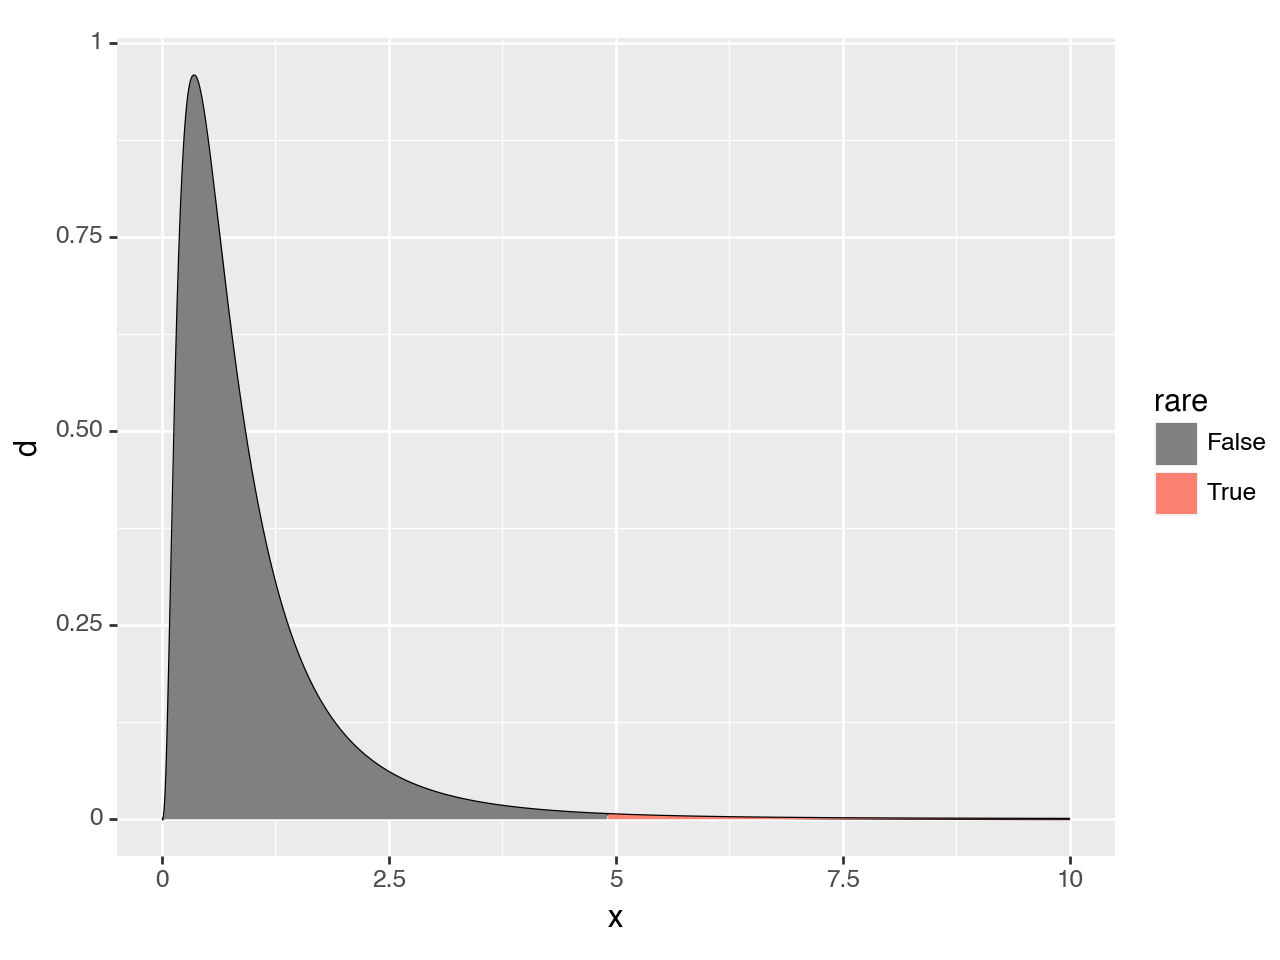

<Figure Size: (640 x 480)>

In [2]:
mg_ref = gr.marg_mom("lognorm", mean=1, sd=1, floc=0)

x_crit = mg_ref.q(1 - 1e-2)
(
    gr.df_make(x=gr.linspace(0, 10, 1000))
    >> gr.tf_mutate(
        d=mg_ref.d(DF.x),
        rare=DF.x > x_crit
    )
    >> gr.ggplot(gr.aes("x", "d"))
    + gr.geom_line()
    + gr.geom_ribbon(
        gr.aes(ymin=0, ymax="d", fill="rare"),
    )
    + gr.scale_fill_manual(
        values={True: "salmon", False: "grey"}
    )
)

In [3]:
# Set the true Pr value
p_true = 1e-3
x_crit = mg_ref.q(1 - 1e-3)

# Monte Carlo simulation at a few different sample sizes
N_all = [10, 100, 1000, 10000]
df_res = gr.df_grid()
for n in N_all:
    df_tmp = (
        gr.df_make(x=mg_ref.r(n))
        >> gr.tf_summarize(
            p_est=gr.pr(DF.x > x_crit),
            p_up=gr.pr_up(DF.x > x_crit),
        )
        >> gr.tf_mutate(n=n)
    )
    df_res = (
        df_res
        >> gr.tf_bind_rows(df_tmp)
    )
df_res

,p_est,p_up,n
0,0.0000,0.440698,10
1,0.0000,0.073039,100
2,0.0000,0.007818,1000
3,0.0008,0.002078,10000


## FORM

### Example: Convex safe set

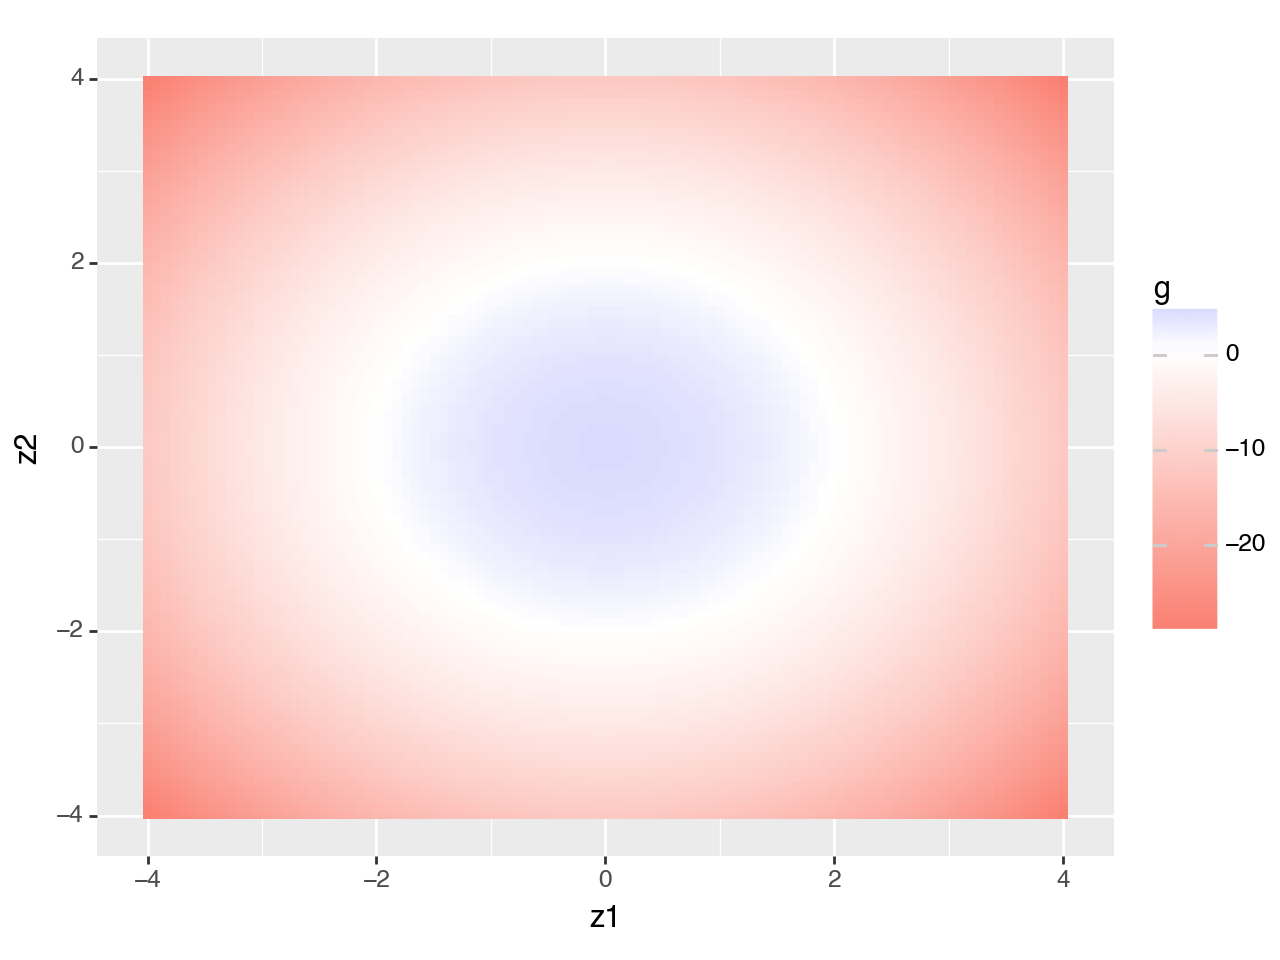

<Figure Size: (640 x 480)>

In [4]:
md_convex = (
    gr.Model("Convex safe set")
    >> gr.cp_vec_function(
        fun=lambda df: df
        >> gr.tf_mutate(g=4 - df.z1**2 - df.z2**2),
        var=["z1", "z2"],
        out=["g"],
    )
    >> gr.cp_marginals(
        z1=gr.marg_mom("norm", mean=0, sd=1),
        z2=gr.marg_mom("norm", mean=0, sd=1),
    )
    >> gr.cp_copula_independence()
)

(
    gr.df_grid(
        z1=gr.linspace(-4, +4, 100), 
        z2=gr.linspace(-4, +4, 100), 
    )
    >> gr.tf_md(md_convex)
    >> gr.ggplot(gr.aes("z1", "z2"))
    + gr.geom_tile(gr.aes(fill="g"))
    + gr.scale_fill_gradient2(
        low="salmon",
        high="blue",
        midpoint=0,
    )
)

Do we expect FORM to over- or under-estimate the reliability?

In [5]:
## Monte Carlo
(
    md_convex
    >> gr.ev_sample(df_det="nom", n=1e2)
    >> gr.tf_summarize(
        p_lo=gr.pr_lo(DF.g > 0),
        p_safe=gr.pr(DF.g > 0),
        p_up=gr.pr_up(DF.g > 0),
    )
    >> gr.tf_mutate(
        beta=gr.qnorm(DF.p_safe)
    )
)

eval_sample() is rounding n...


,p_lo,p_safe,p_up,beta
0,0.678945,0.81,0.895771,0.877896


In [6]:
(
    md_convex
    >> gr.ev_form_ria(
        df_det="nom",
        limits=["g"],
        format="rels",
    )
)

,z1,z2,rel_g
0,1.414214,1.414213,0.97725


### Example: Shallow

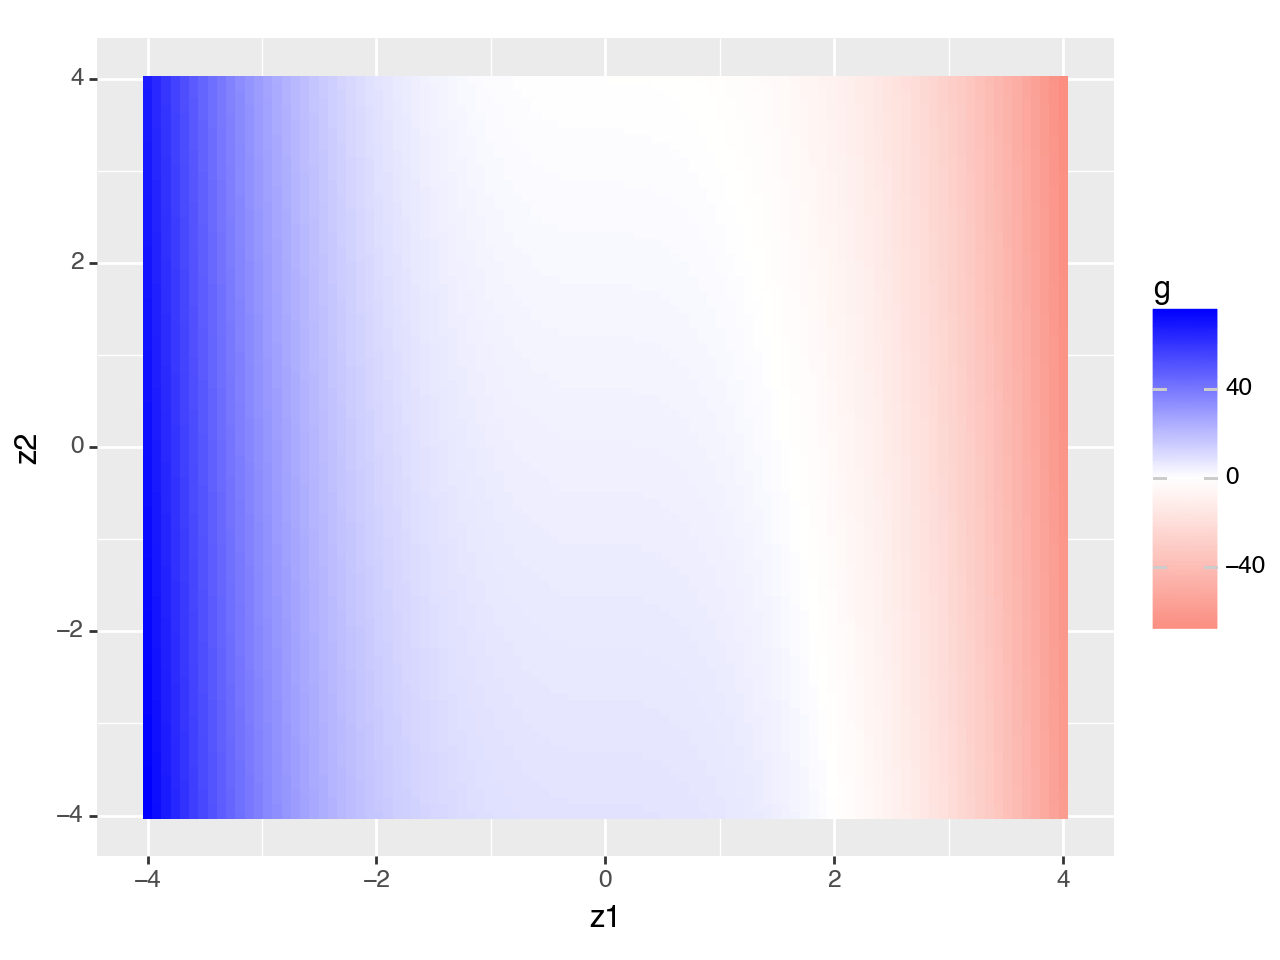

<Figure Size: (640 x 480)>

In [7]:
md_shallow = (
    gr.Model("Shallow curving limit surface")
    >> gr.cp_vec_function(
        fun=lambda df: df
        >> gr.tf_mutate(g=4 - df.z1**3 - df.z2**1),
        var=["z1", "z2"],
        out=["g"],
    )
    >> gr.cp_marginals(
        z1=gr.marg_mom("norm", mean=0, sd=1),
        z2=gr.marg_mom("norm", mean=0, sd=1),
    )
    >> gr.cp_copula_independence()
)

(
    gr.df_grid(
        z1=gr.linspace(-4, +4, 100), 
        z2=gr.linspace(-4, +4, 100), 
    )
    >> gr.tf_md(md_shallow)
    >> gr.ggplot(gr.aes("z1", "z2"))
    + gr.geom_tile(gr.aes(fill="g"))
    + gr.scale_fill_gradient2(
        low="salmon",
        high="blue",
        midpoint=0,
    )
)

Do we expect FORM to over- or under-estimate the reliability?

In [8]:
## Monte Carlo
(
    md_shallow
    >> gr.ev_sample(df_det="nom", n=1e2)
    >> gr.tf_summarize(
        p_lo=gr.pr_lo(DF.g > 0),
        p_safe=gr.pr(DF.g > 0),
        p_up=gr.pr_up(DF.g > 0),
    )
    >> gr.tf_mutate(
        beta=gr.qnorm(DF.p_safe)
    )
)

eval_sample() is rounding n...


,p_lo,p_safe,p_up,beta
0,0.849681,0.95,0.984583,1.644854


In [9]:
(
    md_shallow
    >> gr.ev_form_ria(
        df_det="nom",
        limits=["g"],
        format="rels",
    )
)

,z1,z2,rel_g
0,1.558395,0.215536,0.942167


## Optimization with FORM

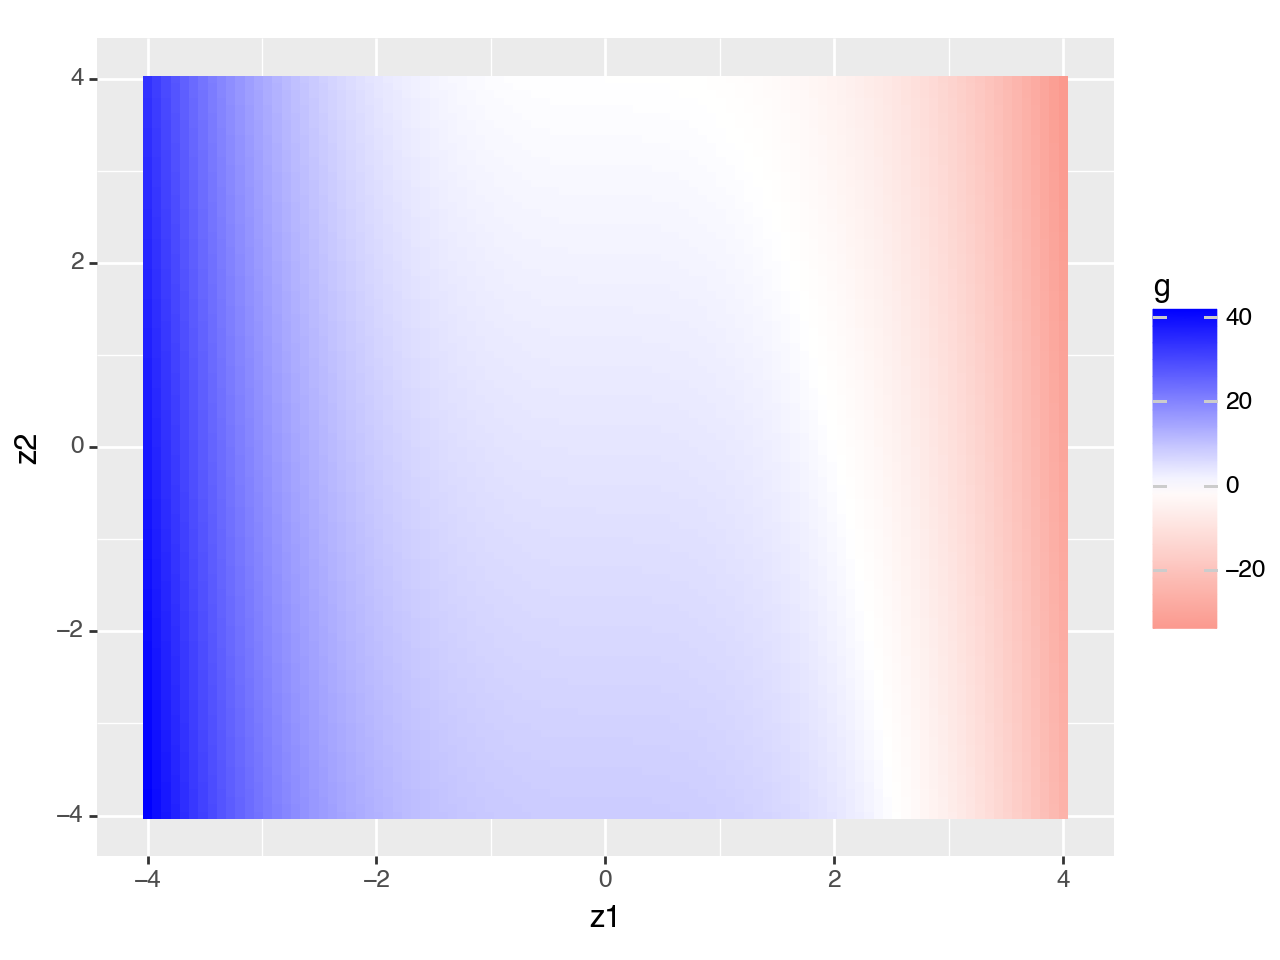

<Figure Size: (640 x 480)>

In [10]:
md_param = (
    gr.Model("Parameterized limit surface")
    >> gr.cp_vec_function(
        fun=lambda df: df
        >> gr.tf_mutate(g=4 - df.c * df.z1**3 - df.z2**1),
        var=["z1", "z2", "c"],
        out=["g"],
    )
    >> gr.cp_marginals(
        z1=gr.marg_mom("norm", mean=0, sd=1),
        z2=gr.marg_mom("norm", mean=0, sd=1),
    )
    >> gr.cp_copula_independence()
    >> gr.cp_bounds(c=(0.1, 1))
)

(
    gr.df_grid(
        z1=gr.linspace(-4, +4, 100), 
        z2=gr.linspace(-4, +4, 100), 
        c=0.5, # CHANGE ME
    )
    >> gr.tf_md(md_param)
    >> gr.ggplot(gr.aes("z1", "z2"))
    + gr.geom_tile(gr.aes(fill="g"))
    + gr.scale_fill_gradient2(
        low="salmon",
        high="blue",
        midpoint=0,
    )
)

$$\max\, c^2$$
$$\text{wrt}\, c$$
$$\text{s.t.}\, \mathbb{P}[g(\vec{Z}; c) > 0] \geq 0.95$$

In [16]:
md_opt = (
    gr.Model()
    >> gr.cp_vec_function(
        fun=lambda df:
        md_param
        >> gr.ev_form_pma(
            pofs={"g": 1e-4},
            # pofs={"g": 5e-2},
            df_det=df,
        )
        >> gr.tf_mutate(obj=-DF.c**2),
        var=["c"],
        out=["obj", "g"],
    )
    >> gr.cp_bounds(c=(0.1, 1))
)

md_opt >> gr.ev_df(gr.df_make(c=0.5))

/Users/zach/opt/anaconda3/envs/pdo/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
/Users/zach/opt/anaconda3/envs/pdo/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract


,c,g,obj
0,0.5,NaN,-0.25


Run optimization

In [12]:
(
    md_opt
    >> gr.ev_min(
        out_min="obj",
        out_geq=["g"]
    )
)

Estimated runtime: 0.0000 sec


,c,c_0,g,obj,success,message,n_iter
0,0.872521,0.55,0.00021,-0.761292,True,Optimization terminated successfully,5
